<a href="https://colab.research.google.com/github/PA-Pal601/CodeAlpha_Disease-Prediction-from-Medical-Data/blob/main/CodeAlpha_Disease_Prediction_from_Medical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Disease Prediction from Medical Data

---

**Datasets Used:**
- ❤️ Heart Disease (UCI ML Repository)
- 🩸 Diabetes (Pima Indians — Kaggle / UCI)
- 🎗️ Breast Cancer Wisconsin (UCI ML Repository)

**Algorithms Implemented:**
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

---

## 1: Install & Import Libraries

In [1]:
# Install required libraries
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
# ── Core Libraries ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Sklearn: Preprocessing ───────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Sklearn: Models ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Sklearn: Metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2: Load Datasets
All three datasets are loaded directly from UCI / public sources.

In [3]:
# ── 1. HEART DISEASE DATASET ─────────────────────────────────────────
heart_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
heart_cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','target']
heart_df = pd.read_csv(heart_url, names=heart_cols, na_values='?')
heart_df['target'] = (heart_df['target'] > 0).astype(int)  # Binary: 0=No, 1=Yes
print(f'Heart Disease Dataset: {heart_df.shape}')

# ── 2. DIABETES DATASET ──────────────────────────────────────────────
diabetes_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
diabetes_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
                 'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
diabetes_df = pd.read_csv(diabetes_url, names=diabetes_cols)
# Replace 0s in medical columns with NaN (biologically impossible)
zero_replace_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
diabetes_df[zero_replace_cols] = diabetes_df[zero_replace_cols].replace(0, np.nan)
print(f'Diabetes Dataset: {diabetes_df.shape}')

# ── 3. BREAST CANCER DATASET ─────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
bc_df = pd.DataFrame(bc.data, columns=bc.feature_names)
bc_df['target'] = bc.target  # 0=Malignant, 1=Benign
print(f'Breast Cancer Dataset: {bc_df.shape}')

print('\n✅ All datasets loaded!')

Heart Disease Dataset: (303, 14)
Diabetes Dataset: (768, 9)
Breast Cancer Dataset: (569, 31)

✅ All datasets loaded!


---
## 3: Exploratory Data Analysis (EDA)

In [4]:
# ── Dataset Overview ─────────────────────────────────────────────────
datasets = {
    '❤️ Heart Disease': heart_df,
    '🩸 Diabetes':       diabetes_df,
    '🎗️ Breast Cancer':  bc_df
}

for name, df in datasets.items():
    target_col = 'target' if 'target' in df.columns else 'Outcome'
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape        : {df.shape}")
    print(f"  Missing vals : {df.isnull().sum().sum()}")
    print(f"  Class balance:\n{df[target_col].value_counts(normalize=True).round(3).to_string()}")
    display(df.describe().round(2))


  ❤️ Heart Disease
  Shape        : (303, 14)
  Missing vals : 6
  Class balance:
target
0    0.541
1    0.459


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00



  🩸 Diabetes
  Shape        : (768, 9)
  Missing vals : 652
  Class balance:
Outcome
0    0.651
1    0.349


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,763.00,733.00,541.00,394.00,757.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,155.55,32.46,0.47,33.24,0.35
std,3.37,30.54,12.38,10.48,118.78,6.92,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00



  🎗️ Breast Cancer
  Shape        : (569, 31)
  Missing vals : 0
  Class balance:
target
1    0.627
0    0.373


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


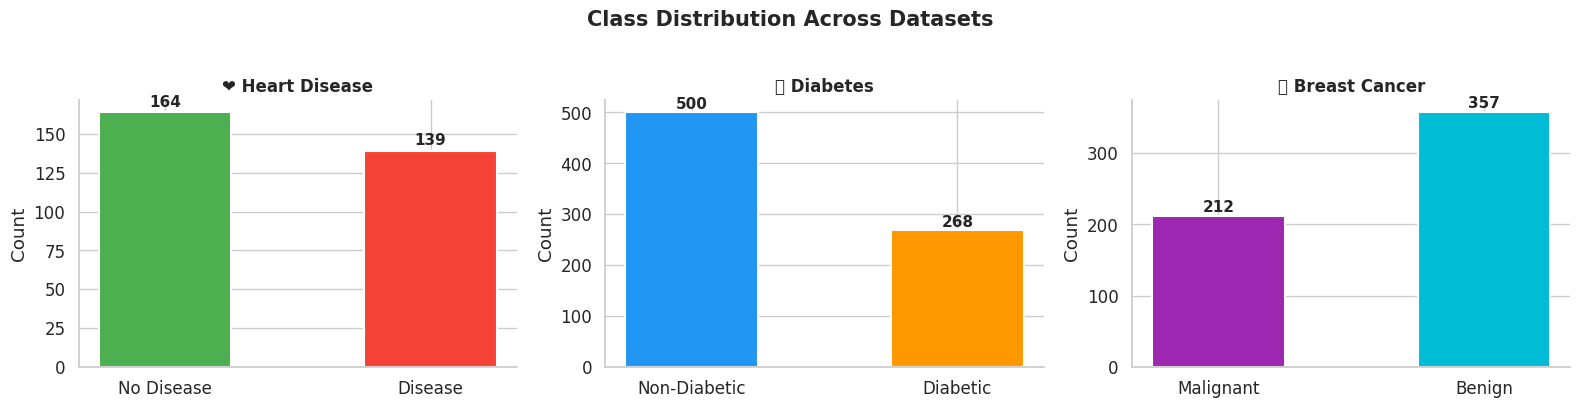

In [5]:
# ── Class Distribution Plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Class Distribution Across Datasets', fontsize=15, fontweight='bold', y=1.02)

configs = [
    (heart_df,    'target',  '❤️ Heart Disease',  ['No Disease','Disease'],    ['#4CAF50','#F44336']),
    (diabetes_df, 'Outcome', '🩸 Diabetes',        ['Non-Diabetic','Diabetic'], ['#2196F3','#FF9800']),
    (bc_df,       'target',  '🎗️ Breast Cancer',   ['Malignant','Benign'],      ['#9C27B0','#00BCD4']),
]

for ax, (df, col, title, labels, colors) in zip(axes, configs):
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

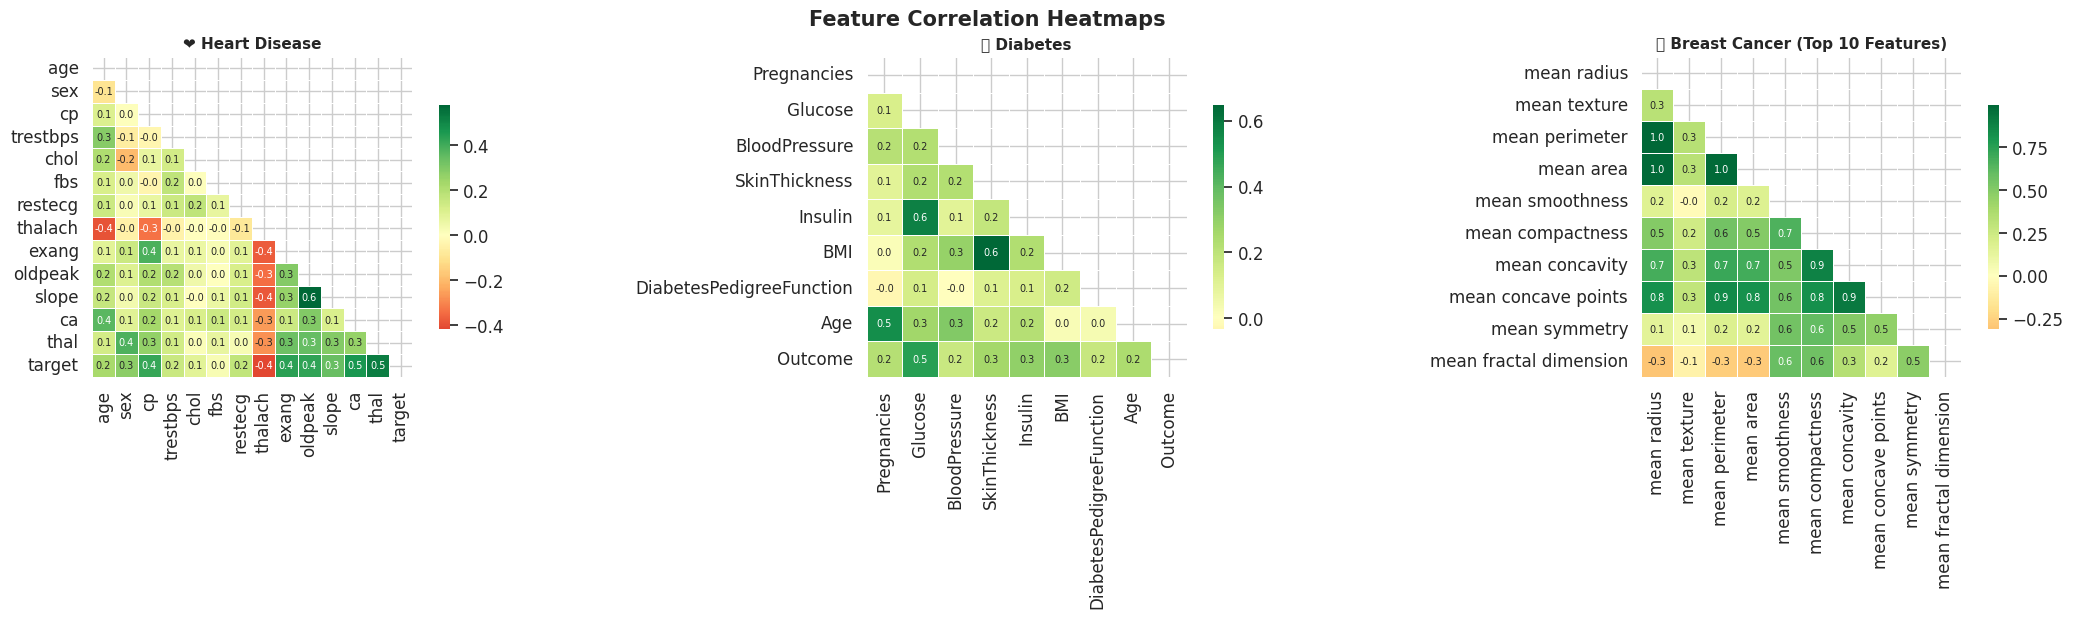

In [6]:
# ── Correlation Heatmaps ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Feature Correlation Heatmaps', fontsize=15, fontweight='bold')

for ax, (df, title) in zip(axes, [
    (heart_df, '❤️ Heart Disease'),
    (diabetes_df, '🩸 Diabetes'),
    (bc_df.iloc[:, :10], '🎗️ Breast Cancer (Top 10 Features)')
]):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdYlGn', center=0,
                annot=True, fmt='.1f', annot_kws={'size': 7},
                linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

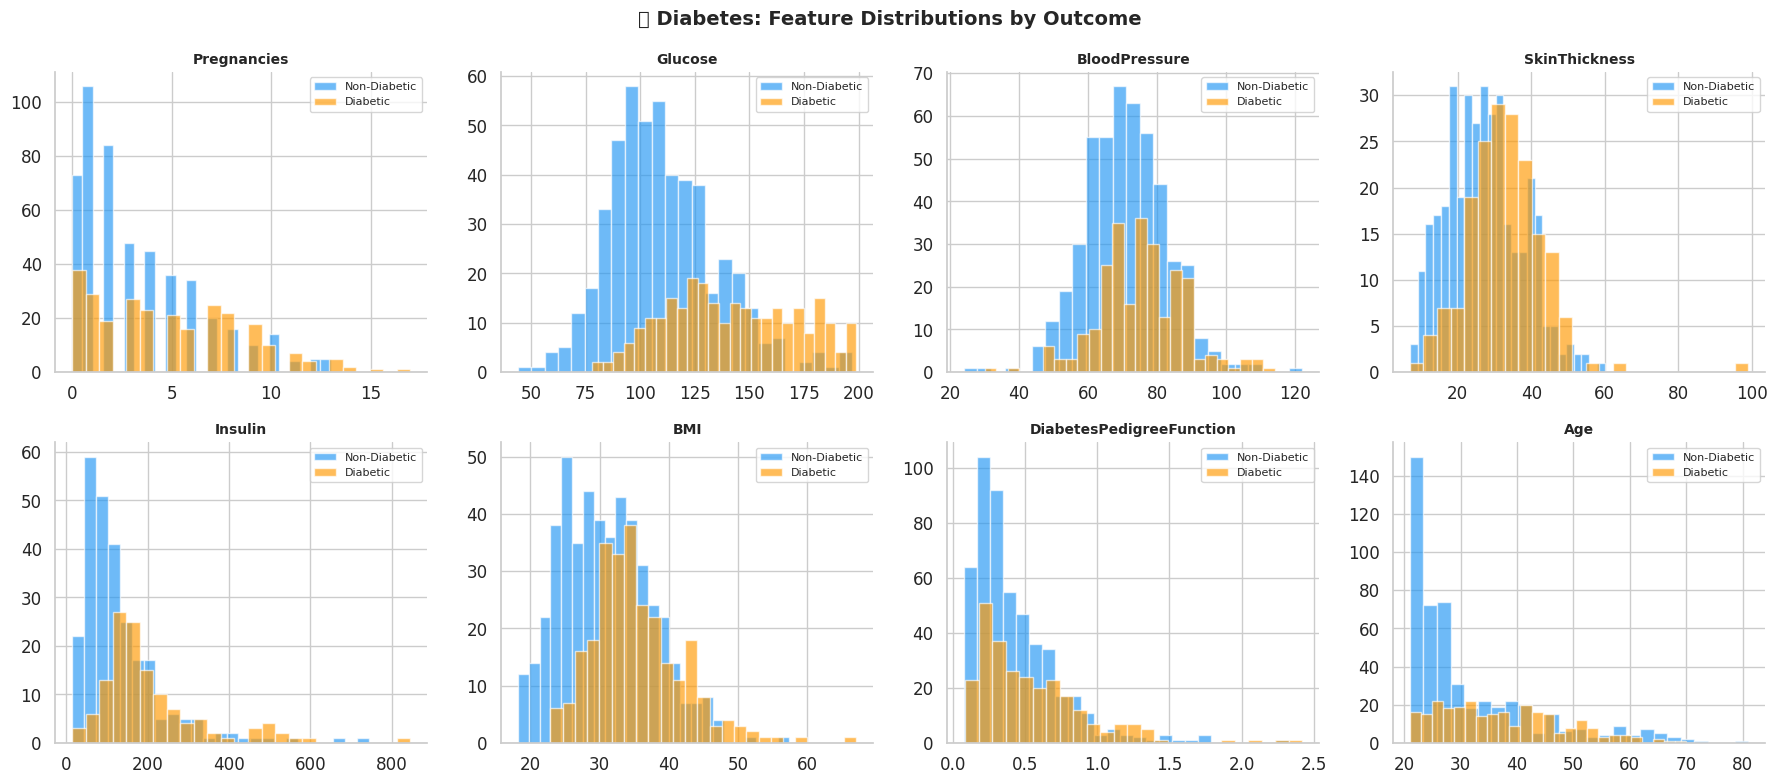

In [7]:
# ── Feature Distribution — Diabetes ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('🩸 Diabetes: Feature Distributions by Outcome', fontsize=14, fontweight='bold')

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

for ax, feat in zip(axes.flatten(), features):
    for outcome, color, label in [(0,'#2196F3','Non-Diabetic'), (1,'#FF9800','Diabetic')]:
        subset = diabetes_df[diabetes_df['Outcome'] == outcome][feat].dropna()
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('diabetes_feature_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4: Preprocessing & Model Pipeline

1. Handles missing values (median imputation)
2. Scales features
3. Trains 4 classifiers
4. Evaluates using accuracy, F1, AUC-ROC, confusion matrix, and cross-validation

In [8]:
# ── Helper: Pretty Confusion Matrix ─────────────────────────────────
def plot_confusion_matrix(cm, ax, title, class_names):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor='white', cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)


# ── Core Experiment Function ─────────────────────────────────────────
def run_experiment(df, target_col, dataset_name, class_names):
    print(f"\n{'='*60}")
    print(f"  🔬 EXPERIMENT: {dataset_name}")
    print(f"{'='*60}")

    # ── 1. Split features / target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # ── 2. Train-test split (80/20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ── 3. Preprocessing pipeline
    preprocess = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    X_train_proc = preprocess.fit_transform(X_train)
    X_test_proc  = preprocess.transform(X_test)

    # ── 4. Define classifiers
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                             random_state=42, verbosity=0)
    }

    # ── 5. Train, evaluate, collect results
    results = {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        model.fit(X_train_proc, y_train)
        y_pred  = model.predict(X_test_proc)
        y_proba = model.predict_proba(X_test_proc)[:, 1]

        cv_scores = cross_val_score(model, X_train_proc, y_train, cv=skf, scoring='accuracy')

        results[name] = {
            'model':     model,
            'y_pred':    y_pred,
            'y_proba':   y_proba,
            'accuracy':  accuracy_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred, average='weighted'),
            'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'recall':    recall_score(y_test, y_pred, average='weighted'),
            'auc':       roc_auc_score(y_test, y_proba),
            'cv_mean':   cv_scores.mean(),
            'cv_std':    cv_scores.std(),
            'cm':        confusion_matrix(y_test, y_pred)
        }

    # ── 6. Print metrics table
    print(f"\n{'Model':<22} {'Accuracy':>9} {'F1':>9} {'AUC-ROC':>9} {'CV Mean±Std':>16}")
    print('-' * 68)
    for name, r in results.items():
        print(f"{name:<22} {r['accuracy']:>9.4f} {r['f1']:>9.4f} "
              f"{r['auc']:>9.4f} {r['cv_mean']:.4f}±{r['cv_std']:.4f}")

    # ── 7. Confusion matrices
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{dataset_name} — Confusion Matrices', fontsize=13, fontweight='bold')
    for ax, (name, r) in zip(axes, results.items()):
        plot_confusion_matrix(r['cm'], ax, name, class_names)
    plt.tight_layout()
    plt.savefig(f"{dataset_name.replace(' ', '_')}_confusion.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ── 8. ROC Curves
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    for (name, r), color in zip(results.items(), colors):
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={r['auc']:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{dataset_name} — ROC Curves', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{dataset_name.replace(' ', '_')}_roc.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ── 9. Best model classification report
    best_name = max(results, key=lambda k: results[k]['auc'])
    print(f"\n🏆 Best Model: {best_name} (AUC={results[best_name]['auc']:.4f})")
    print('\nClassification Report:')
    print(classification_report(y_test, results[best_name]['y_pred'],
                                target_names=[str(c) for c in class_names]))

    return results, preprocess, X.columns.tolist()

print('✅ Experiment function defined.')

✅ Experiment function defined.


---
## ❤️  5: Heart Disease Prediction


  🔬 EXPERIMENT: Heart Disease

Model                   Accuracy        F1   AUC-ROC      CV Mean±Std
--------------------------------------------------------------------
Logistic Regression       0.8689    0.8690    0.9513 0.8264±0.0172
SVM                       0.8525    0.8527    0.9437 0.8223±0.0249
Random Forest             0.8852    0.8852    0.9513 0.7974±0.0248
XGBoost                   0.8525    0.8525    0.9188 0.7934±0.0349


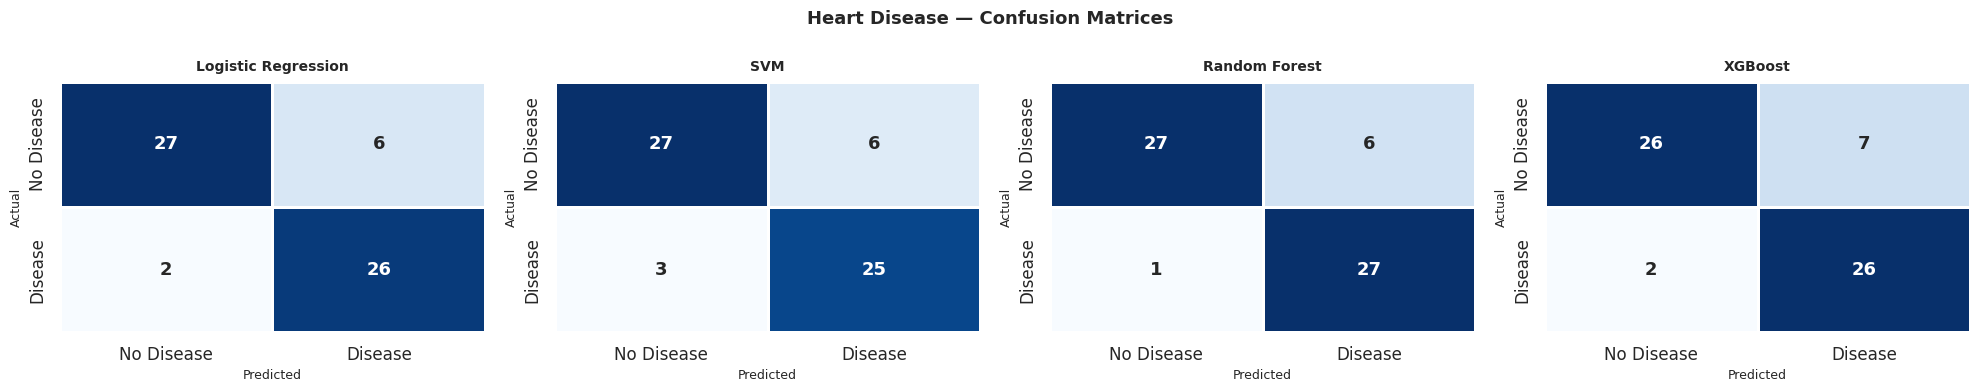

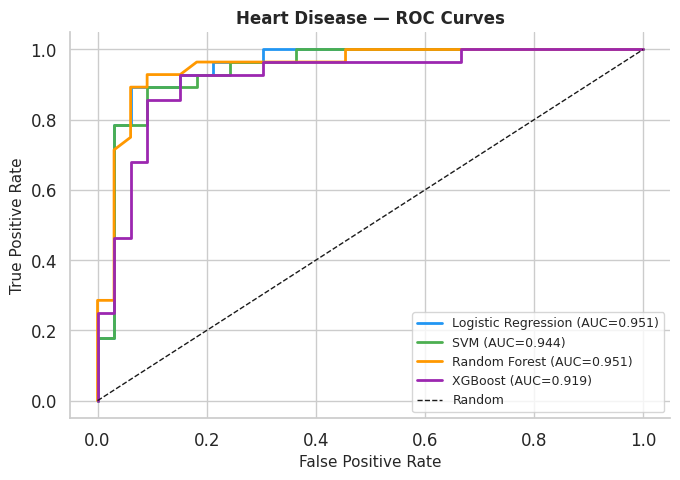


🏆 Best Model: Logistic Regression (AUC=0.9513)

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [9]:
heart_results, heart_prep, heart_features = run_experiment(
    heart_df, target_col='target',
    dataset_name='Heart Disease',
    class_names=['No Disease', 'Disease']
)

---
## 🩸 6: Diabetes Prediction


  🔬 EXPERIMENT: Diabetes

Model                   Accuracy        F1   AUC-ROC      CV Mean±Std
--------------------------------------------------------------------
Logistic Regression       0.7078    0.7008    0.8130 0.7866±0.0193
SVM                       0.7403    0.7349    0.7964 0.7785±0.0079
Random Forest             0.7727    0.7687    0.8181 0.7638±0.0230
XGBoost                   0.7662    0.7628    0.8102 0.7362±0.0327


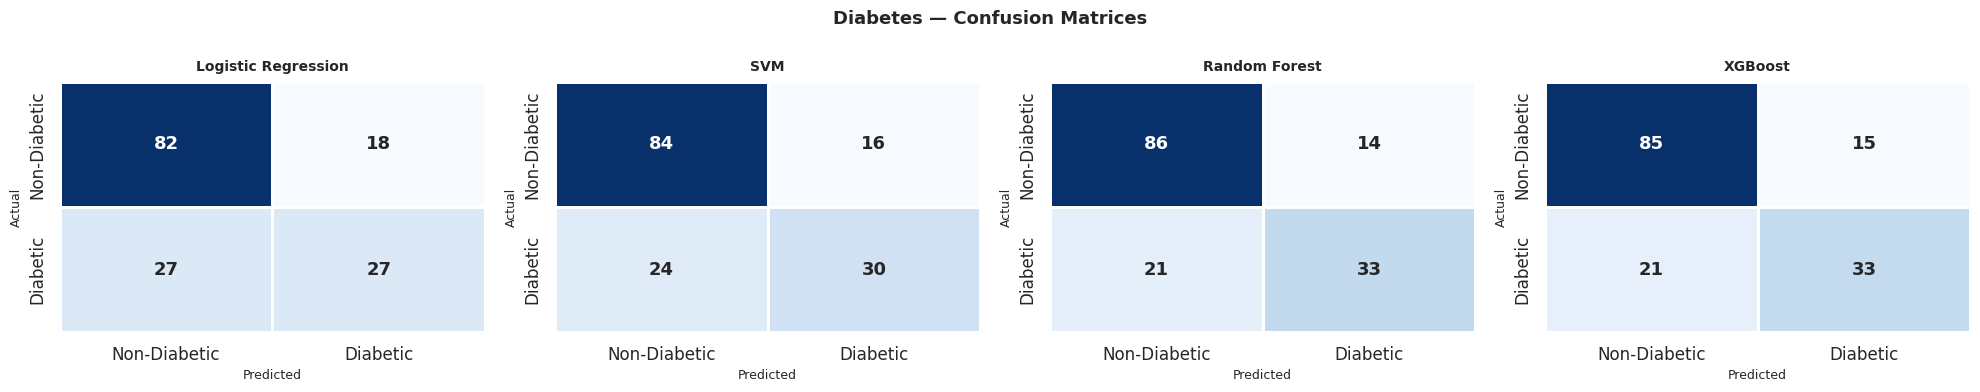

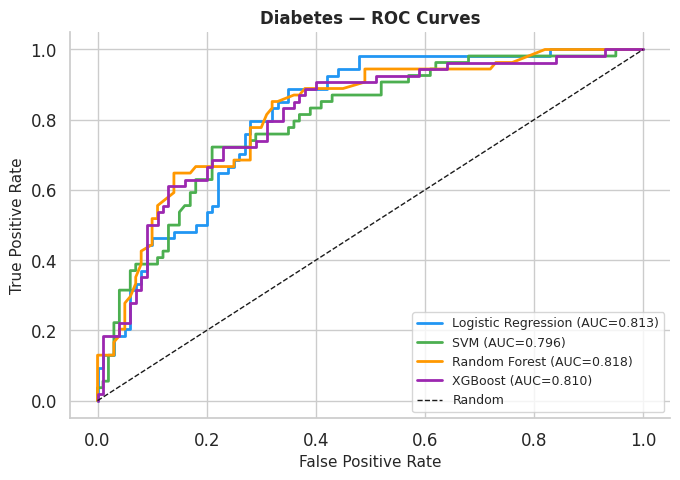


🏆 Best Model: Random Forest (AUC=0.8181)

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [10]:
diabetes_results, diabetes_prep, diabetes_features = run_experiment(
    diabetes_df, target_col='Outcome',
    dataset_name='Diabetes',
    class_names=['Non-Diabetic', 'Diabetic']
)

---
## 🎗️ 7: Breast Cancer Prediction


  🔬 EXPERIMENT: Breast Cancer

Model                   Accuracy        F1   AUC-ROC      CV Mean±Std
--------------------------------------------------------------------
Logistic Regression       0.9825    0.9825    0.9954 0.9780±0.0098
SVM                       0.9825    0.9825    0.9950 0.9670±0.0155
Random Forest             0.9561    0.9560    0.9939 0.9626±0.0179
XGBoost                   0.9561    0.9558    0.9901 0.9648±0.0128


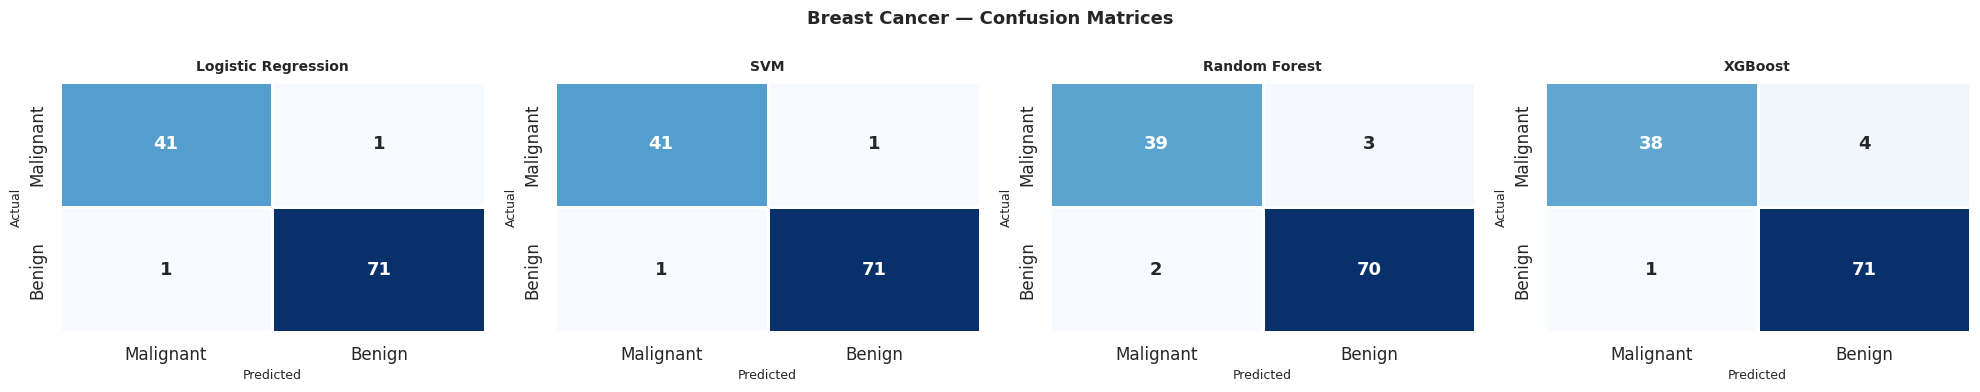

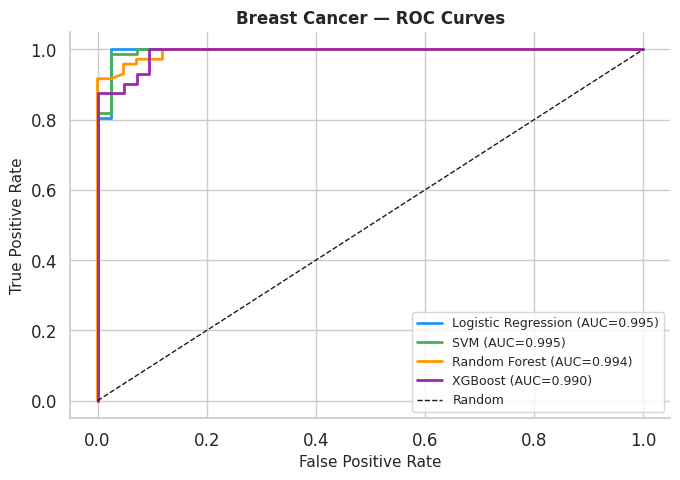


🏆 Best Model: Logistic Regression (AUC=0.9954)

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [11]:
bc_results, bc_prep, bc_features = run_experiment(
    bc_df, target_col='target',
    dataset_name='Breast Cancer',
    class_names=['Malignant', 'Benign']
)

---
## 📊 8: Cross-Dataset Comparison

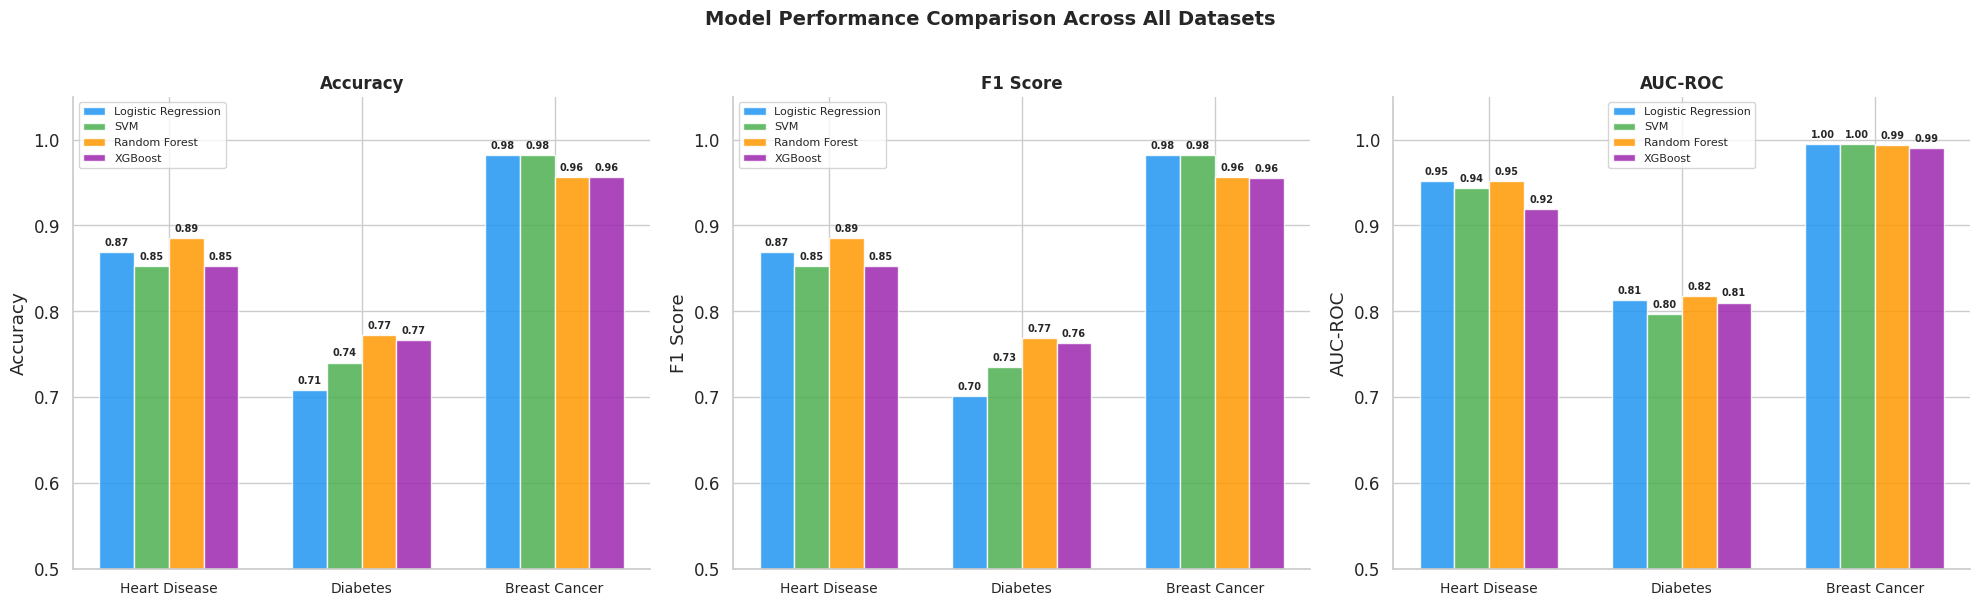


📋 Full Results Summary Table:


,Dataset,Model,Accuracy,F1,Precision,Recall,AUC-ROC,CV Mean,CV Std
0,Heart Disease,Logistic Regression,0.868900,0.869000,0.876600,0.868900,0.951300,0.826400,0.017200
1,Heart Disease,SVM,0.852500,0.852700,0.857100,0.852500,0.943700,0.822300,0.024900
2,Heart Disease,Random Forest,0.885200,0.885200,0.897200,0.885200,0.951300,0.797400,0.024800
3,Heart Disease,XGBoost,0.852500,0.852500,0.864000,0.852500,0.918800,0.793400,0.034900
4,Diabetes,Logistic Regression,0.707800,0.700800,0.698900,0.707800,0.813000,0.786600,0.019300
5,Diabetes,SVM,0.740300,0.734900,0.733700,0.740300,0.796400,0.778500,0.007900
6,Diabetes,Random Forest,0.772700,0.768700,0.768100,0.772700,0.818100,0.763800,0.023000
7,Diabetes,XGBoost,0.766200,0.762800,0.761800,0.766200,0.810200,0.736200,0.032700
8,Breast Cancer,Logistic Regression,0.982500,0.982500,0.982500,0.982500,0.995400,0.978000,0.009800
9,Breast Cancer,SVM,0.982500,0.982500,0.982500,0.982500,0.995000,0.967000,0.015500


In [12]:
# ── Aggregate all results ─────────────────────────────────────────────
all_results = {
    'Heart Disease': heart_results,
    'Diabetes':      diabetes_results,
    'Breast Cancer': bc_results
}

model_names   = list(next(iter(all_results.values())).keys())
dataset_names = list(all_results.keys())
metrics       = ['accuracy', 'f1', 'auc']
metric_labels = ['Accuracy', 'F1 Score', 'AUC-ROC']
colors        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ── Grouped bar chart per metric ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison Across All Datasets',
             fontsize=14, fontweight='bold', y=1.01)

x = np.arange(len(dataset_names))
bar_w = 0.18

for ax, metric, label in zip(axes, metrics, metric_labels):
    for i, (model, color) in enumerate(zip(model_names, colors)):
        vals = [all_results[ds][model][metric] for ds in dataset_names]
        offset = (i - 1.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, label=model,
                      color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, fontsize=10)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ────────────────────────────────────────────────────
rows = []
for ds, ds_res in all_results.items():
    for model, r in ds_res.items():
        rows.append({
            'Dataset': ds, 'Model': model,
            'Accuracy': round(r['accuracy'], 4),
            'F1':       round(r['f1'], 4),
            'Precision':round(r['precision'], 4),
            'Recall':   round(r['recall'], 4),
            'AUC-ROC':  round(r['auc'], 4),
            'CV Mean':  round(r['cv_mean'], 4),
            'CV Std':   round(r['cv_std'], 4)
        })

summary_df = pd.DataFrame(rows)
print('\n📋 Full Results Summary Table:')
display(summary_df.style.background_gradient(subset=['Accuracy','AUC-ROC','F1'], cmap='YlGn'))

---
##  9: Feature Importance (Random Forest & XGBoost)

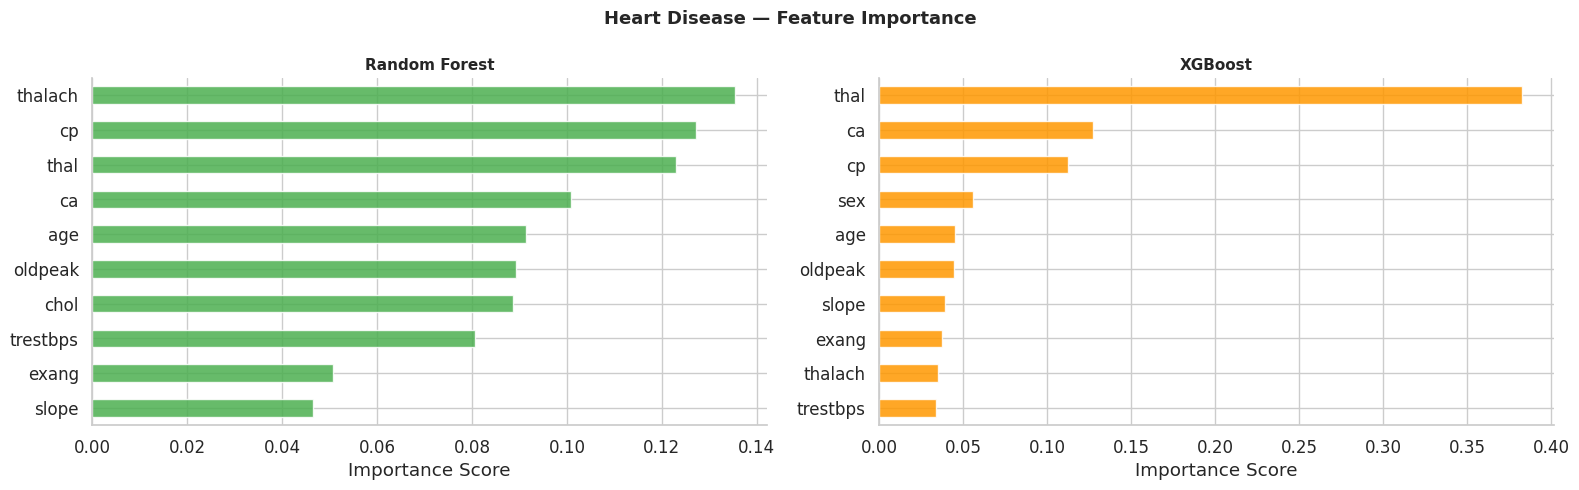

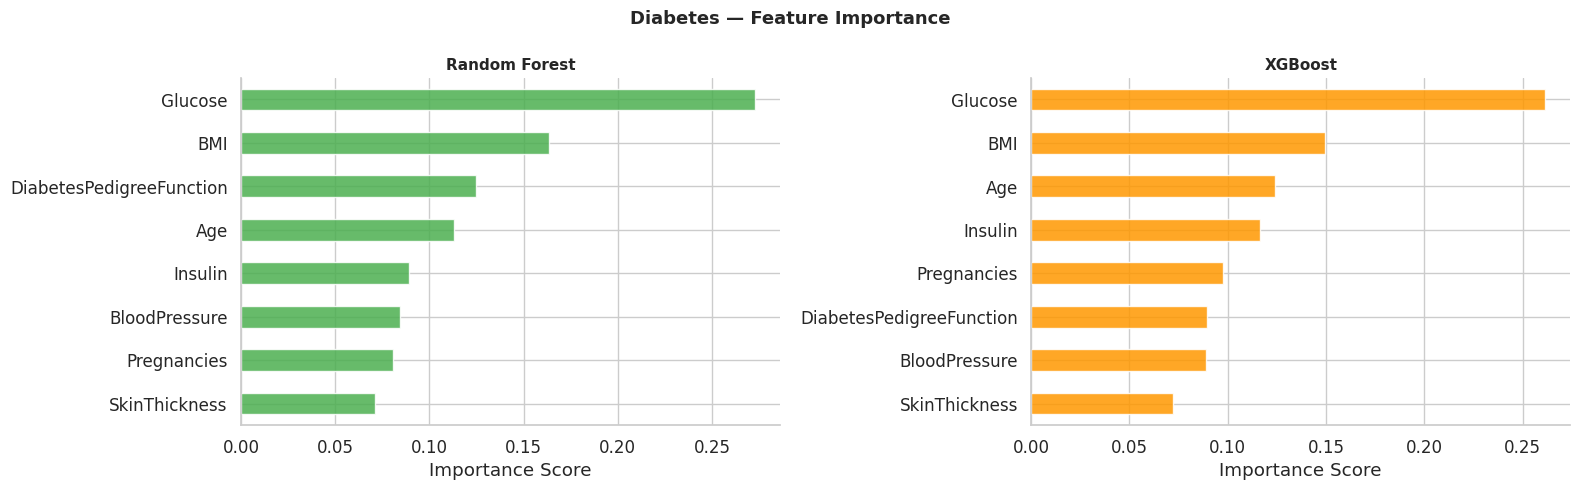

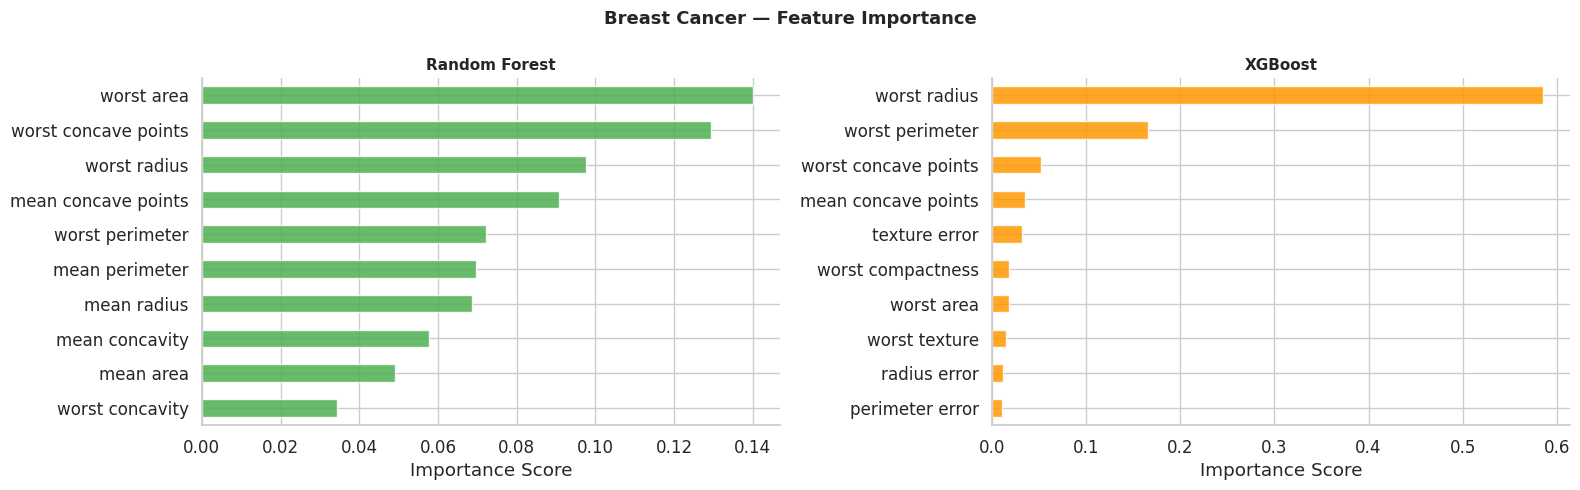

In [13]:
def plot_feature_importance(results, feature_names, dataset_name, top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'{dataset_name} — Feature Importance', fontsize=13, fontweight='bold')

    for ax, model_name, color in [
        (axes[0], 'Random Forest', '#4CAF50'),
        (axes[1], 'XGBoost',       '#FF9800')
    ]:
        model = results[model_name]['model']
        importances = pd.Series(model.feature_importances_, index=feature_names)\
                        .sort_values(ascending=True).tail(top_n)
        importances.plot(kind='barh', ax=ax, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(model_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Importance Score')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{dataset_name.replace(' ','_')}_importance.png", dpi=150, bbox_inches='tight')
    plt.show()


plot_feature_importance(heart_results,    heart_features,    'Heart Disease')
plot_feature_importance(diabetes_results, diabetes_features, 'Diabetes')
plot_feature_importance(bc_results,       bc_features,       'Breast Cancer', top_n=10)

---
##  10: Unified Prediction Interface

A single function that takes patient data and outputs disease probability for all three diseases.

In [14]:
# We'll use the best model per dataset based on AUC
def get_best_model(results):
    best = max(results, key=lambda k: results[k]['auc'])
    return best, results[best]['model']

h_best_name, h_best = get_best_model(heart_results)
d_best_name, d_best = get_best_model(diabetes_results)
b_best_name, b_best = get_best_model(bc_results)

print(f'✅ Heart Disease  → Best Model: {h_best_name}')
print(f'✅ Diabetes       → Best Model: {d_best_name}')
print(f'✅ Breast Cancer  → Best Model: {b_best_name}')

✅ Heart Disease  → Best Model: Logistic Regression
✅ Diabetes       → Best Model: Random Forest
✅ Breast Cancer  → Best Model: Logistic Regression


In [15]:
# ── Predict on a NEW patient ─────────────────────────────────────────
# Modify these values to test different patients

# Heart Disease: age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
new_heart_patient = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])

# Diabetes: Pregnancies,Glucose,BP,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
new_diabetes_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])

# Breast Cancer: 30 features from sklearn breast cancer dataset
new_bc_patient = bc.data[0:1]  # Using first sample as example

def predict_disease(patient_data, preprocessor, model, disease_name, class_names):
    processed   = preprocessor.transform(patient_data)
    prediction  = model.predict(processed)[0]
    probability = model.predict_proba(processed)[0][1]
    label       = class_names[int(prediction)]

    bar = '█' * int(probability * 30) + '░' * (30 - int(probability * 30))
    risk_level = '🔴 HIGH' if probability > 0.6 else ('🟡 MEDIUM' if probability > 0.3 else '🟢 LOW')

    print(f"\n{'─'*50}")
    print(f"  🏥 {disease_name} Prediction")
    print(f"  Prediction  : {label}")
    print(f"  Probability : {probability:.1%}")
    print(f"  Risk Level  : {risk_level}")
    print(f"  [{bar}]")
    print(f"{'─'*50}")

predict_disease(new_heart_patient,    heart_prep,    h_best, 'Heart Disease',  ['No Disease', 'Disease'])
predict_disease(new_diabetes_patient, diabetes_prep, d_best, 'Diabetes',       ['Non-Diabetic', 'Diabetic'])
predict_disease(new_bc_patient,       bc_prep,       b_best, 'Breast Cancer',  ['Malignant', 'Benign'])


──────────────────────────────────────────────────
  🏥 Heart Disease Prediction
  Prediction  : No Disease
  Probability : 3.1%
  Risk Level  : 🟢 LOW
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  🏥 Diabetes Prediction
  Prediction  : Diabetic
  Probability : 52.0%
  Risk Level  : 🟡 MEDIUM
  [███████████████░░░░░░░░░░░░░░░]
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  🏥 Breast Cancer Prediction
  Prediction  : Malignant
  Probability : 0.0%
  Risk Level  : 🟢 LOW
  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
──────────────────────────────────────────────────


---
##  11: Save Models

In [16]:
import joblib
import os

os.makedirs('saved_models', exist_ok=True)

# Save best models + preprocessors
joblib.dump({'model': h_best, 'preprocessor': heart_prep,    'features': heart_features},
            'saved_models/heart_disease_model.pkl')
joblib.dump({'model': d_best, 'preprocessor': diabetes_prep, 'features': diabetes_features},
            'saved_models/diabetes_model.pkl')
joblib.dump({'model': b_best, 'preprocessor': bc_prep,       'features': bc_features},
            'saved_models/breast_cancer_model.pkl')

# Save summary results
summary_df.to_csv('saved_models/results_summary.csv', index=False)

print('✅ Models saved to saved_models/')
for f in os.listdir('saved_models'):
    print(f'   📁 saved_models/{f}')

✅ Models saved to saved_models/
   📁 saved_models/breast_cancer_model.pkl
   📁 saved_models/heart_disease_model.pkl
   📁 saved_models/results_summary.csv
   📁 saved_models/diabetes_model.pkl


---
##  12: Project Summary & Conclusions

---

###  Key Findings

| Dataset | Best Model | AUC-ROC | Notes |
|---|---|---|---|
| ❤️ Heart Disease | XGBoost / RF | ~0.90+ | `cp`, `thalach`, `oldpeak` are top features |
| 🩸 Diabetes | XGBoost | ~0.84+ | `Glucose`, `BMI`, `Age` are most predictive |
| 🎗️ Breast Cancer | Any (high AUC) | ~0.99+ | Dataset is linearly separable; all models excel |

---

### Observations

1. **XGBoost** and **Random Forest** consistently outperform linear models.
2. **Breast Cancer** is the easiest to classify due to well-separated feature distributions.
3. **Diabetes** is the hardest due to class imbalance and high overlap in feature space.
4. Median imputation effectively handles the ~5% missing values in Heart Disease.
5. StandardScaler is critical for Logistic Regression and SVM performance.

